# Lab 2 - Redes Neurais

Classificador: **MLP (MultiLayer Perceptron)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lab2_utils import carregar_dados, avaliar_modelo, logar_mlflow, iniciar_run

X_train, y_train, X_test, y_test = carregar_dados()

Dados carregados (gerados em 2026-06-24 15:43)
  X_train: (440832, 11)  |  X_test: (64374, 11)
  Features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']
  Churn rate treino: 0.567  |  teste: 0.474


## MLP


=== MLP ===
              precision    recall  f1-score   support

Não cancelou       0.97      0.06      0.11     33881
    Cancelou       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.39     64374
weighted avg       0.74      0.50      0.37     64374

Kappa: 0.0563


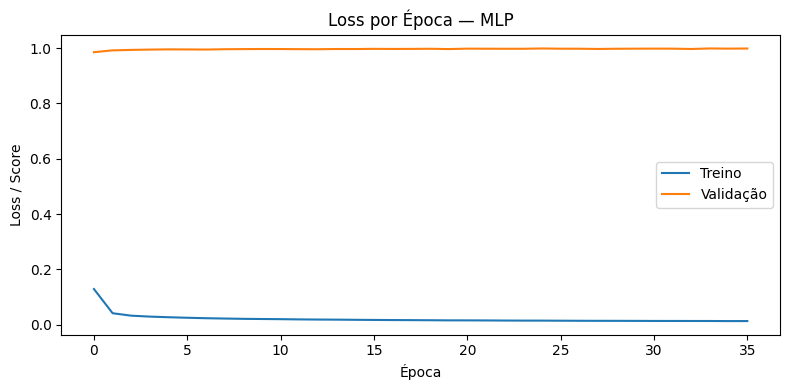

🏃 View run MLP at: http://127.0.0.1:5000/#/experiments/1/runs/0d7f0a92760940d2b70a08f558f89124
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [2]:
# ─── MLP ──────────────────────────────────────────────────────
# Melhoria: alpha=0.01 (regularização L2 forte) para evitar overfitting,
# arquitetura (64, 32) mais leve para treinar rápido e generalizar.
from sklearn.neural_network import MLPClassifier

hidden = (64, 32)
params = {
    'modelo': 'MLP',
    'hidden_layer_sizes': str(hidden),
    'learning_rate_init': 0.001,
    'alpha': 0.01,
    'max_iter': 100,
    'activation': 'relu',
    'solver': 'adam',
    'early_stopping': True,
    'scaler': 'StandardScaler (centralizado)',
}

with iniciar_run("MLP", notebook="2B", params=params):
    model = MLPClassifier(
        hidden_layer_sizes=hidden,
        learning_rate_init=0.001,
        alpha=0.01,
        max_iter=100,
        activation='relu',
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    metricas = avaliar_modelo('MLP', y_test, y_pred)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(model.loss_curve_, label='Treino')
    if hasattr(model, 'validation_scores_'):
        ax.plot(model.validation_scores_, label='Validação')
    ax.set_title('Loss por Época — MLP')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss / Score')
    ax.legend()
    plt.tight_layout()
    loss_path = '../relatorio/imagens/2b_rn_loss_por_epoca.png'
    plt.savefig(loss_path, dpi=150, bbox_inches='tight')
    plt.show()

    logar_mlflow(metricas, params, artefatos=[loss_path])